In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive"

'Colab Notebooks'   ML_models  'Transcription de texte (data limitée)'	 TrOCR


In [ ]:
%cd "/content/drive/MyDrive/Transcription de texte (data limitée)"

/content/drive/MyDrive/Transcription de texte (data limitée)


In [ ]:
!ls

dataset.py  models  outputs	 tokenizer.py  utils.py
fonts	    module  __pycache__  train.py


In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install timm spikingjelly datasets pillow

Looking in indexes: https://download.pytorch.org/whl/cu121
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 437.6/437.6 kB 33.9 MB/s eta 0:00:00


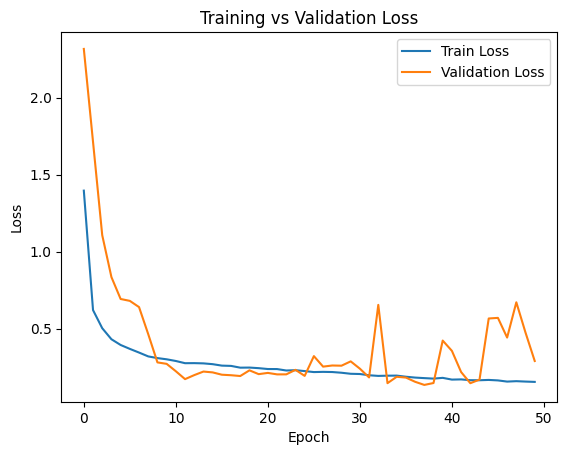

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

train_losses = np.load("/content/drive/MyDrive/Transcription de texte (data limitée)/outputs/sdt_ocr_20260408_115935_/train_losses.npy")
val_losses = np.load("/content/drive/MyDrive/Transcription de texte (data limitée)/outputs/sdt_ocr_20260408_115935_/val_losses.npy")

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [ ]:
import torch
from models.sdt_ocr import SpikeDrivenTransformerOCR
from tokenizer import SimpleTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = SimpleTokenizer()

model = SpikeDrivenTransformerOCR(
    vocab_size=tokenizer.vocab_size,
    img_size_h=32,
    img_size_w=512,
    patch_size=2,
    embed_dims=128,
    depths=4,
    num_heads=4,
    T=4,
    in_channels=1,
    pooling_stat="1110",
)

model.load_state_dict(torch.load(
    "/content/drive/MyDrive/Transcription de texte (data limitée)/outputs/sdt_ocr_20260408_115935_/best_sdt_ocr.pth",
    map_location=device
))

model.to(device)
model.eval()

print("Model loaded successfully ✅")

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


Model loaded successfully ✅


In [ ]:
from dataset import WikiTextImageDataset
from torch.utils.data import DataLoader

test_dataset = WikiTextImageDataset(
    tokenizer=tokenizer,
    max_samples=10000,
    img_size=(32, 512),
    max_chars=32,
    train=False,
    sources=[
        ("wikimedia/wikipedia", "20231101.fr", "Français"),
    ]
)

def collate_fn(batch):
    images = torch.stack([b["pixel_values"] for b in batch])
    labels = [b["labels"] for b in batch]

    label_lengths = torch.tensor([len(l) for l in labels], dtype=torch.long)
    labels = torch.cat(labels)

    return images, labels, label_lengths

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0
)

print("Test loader ready ✅")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Test loader ready ✅


Sur 800 samples

In [ ]:
from utils import greedy_decode, compute_cer
import numpy as np

num_batches = 200 # num batches 200 donc 200 * 4 = 800 samples
all_cer = []

with torch.no_grad():
    for i, (images, labels, label_lengths) in enumerate(test_loader):

        if i >= num_batches:
            break

        images = images.to(device)

        logits = model(images)
        preds = greedy_decode(logits, tokenizer)

        labels = labels.cpu()
        label_lengths = label_lengths.cpu()

        offset = 0

        for b in range(len(preds)):
            length = label_lengths[b].item()
            gt = tokenizer.decode(labels[offset:offset+length].tolist())
            offset += length

            cer = compute_cer(preds[b], gt)
            all_cer.append(cer)

mean_cer = np.mean(all_cer)
print("Mean CER over", len(all_cer), "samples:", round(mean_cer, 4))

Mean CER over 800 samples: 0.0517


In [ ]:
print("Min CER:", np.min(all_cer))
print("Max CER:", np.max(all_cer))
print("Median CER:", np.median(all_cer))

Min CER: 0.0
Max CER: 0.38461538461538464
Median CER: 0.041666666666666664


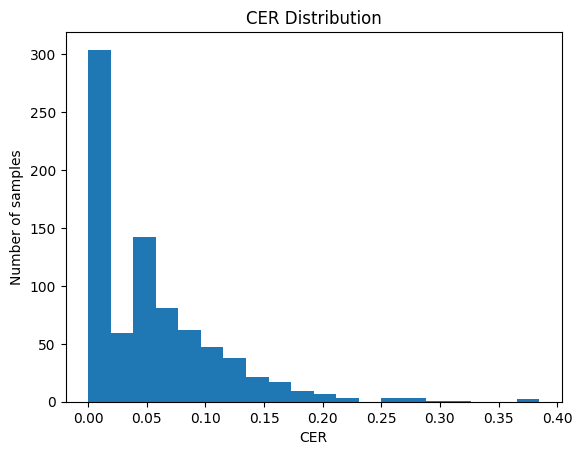

In [ ]:
import matplotlib.pyplot as plt

plt.hist(all_cer, bins=20)
plt.xlabel("CER")
plt.ylabel("Number of samples")
plt.title("CER Distribution")
plt.show()

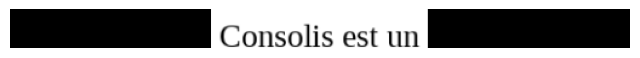

GT   : consolis est un
Pred : consolis est un
CER  : 0.0
--------------------------------------------------


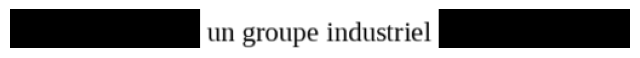

GT   : un groupe industriel
Pred : un groupe industriel
CER  : 0.0
--------------------------------------------------


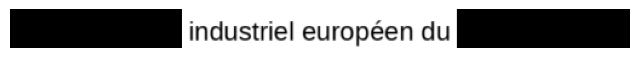

GT   : industriel européen du
Pred : industriel européen du
CER  : 0.0
--------------------------------------------------


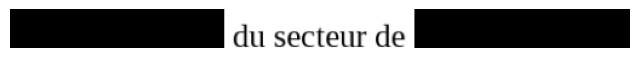

GT   : du secteur de
Pred : du secteur den
CER  : 0.0769
--------------------------------------------------


In [ ]:
from utils import compute_cer

sample = next(iter(test_loader))
images, labels, label_lengths = sample

images = images.to(device)

with torch.no_grad():
    logits = model(images)

preds = greedy_decode(logits, tokenizer)

images = images.cpu()
labels = labels.cpu()
label_lengths = label_lengths.cpu()

offset = 0

for i in range(4):
    length = label_lengths[i].item()
    gt = tokenizer.decode(labels[offset:offset+length].tolist())
    offset += length

    pred = preds[i]

    # calcul du CER
    cer = compute_cer(pred, gt)

    img = images[i].squeeze(0)

    plt.figure(figsize=(8,2))
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.show()

    print("GT   :", gt)
    print("Pred :", pred)
    print("CER  :", round(cer, 4))
    print("-"*50)

Sur 10000 samples

In [ ]:
from utils import greedy_decode, compute_cer
import numpy as np

num_batches = 10000 # num batch 10k donc 4 * 10k = 40k, cependant max_samples = 10k. Donc on aura le max de samples utilisés 10k
all_cer = []

with torch.no_grad():
    for i, (images, labels, label_lengths) in enumerate(test_loader):

        if i >= num_batches:
            break

        images = images.to(device)

        logits = model(images)
        preds = greedy_decode(logits, tokenizer)

        labels = labels.cpu()
        label_lengths = label_lengths.cpu()

        offset = 0

        for b in range(len(preds)):
            length = label_lengths[b].item()
            gt = tokenizer.decode(labels[offset:offset+length].tolist())
            offset += length

            cer = compute_cer(preds[b], gt)
            all_cer.append(cer)

mean_cer = np.mean(all_cer)
print("Mean CER over", len(all_cer), "samples:", round(mean_cer, 4))

Mean CER over 10000 samples: 0.0588


In [ ]:
print("Min CER:", np.min(all_cer))
print("Max CER:", np.max(all_cer))
print("Median CER:", np.median(all_cer))

Min CER: 0.0
Max CER: 1.0
Median CER: 0.043478260869565216


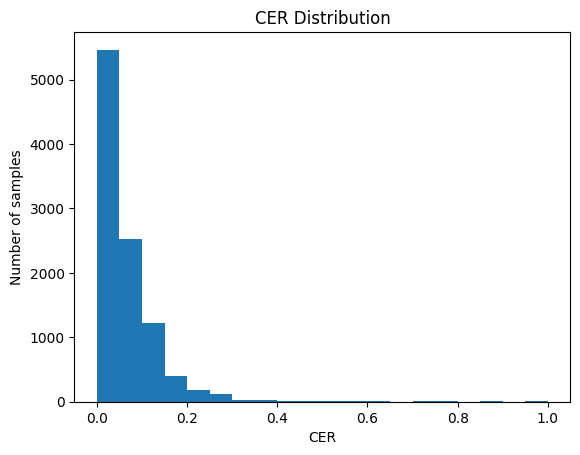

In [ ]:
import matplotlib.pyplot as plt

plt.hist(all_cer, bins=20)
plt.xlabel("CER")
plt.ylabel("Number of samples")
plt.title("CER Distribution")
plt.show()

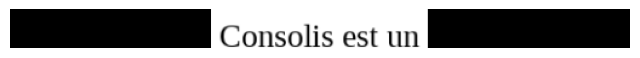

GT   : consolis est un
Pred : consolis est un
CER  : 0.0
--------------------------------------------------


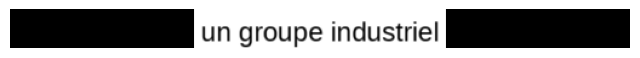

GT   : un groupe industriel
Pred : un groupe industiel
CER  : 0.05
--------------------------------------------------


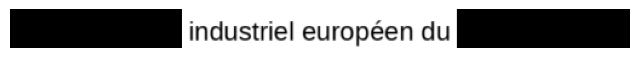

GT   : industriel européen du
Pred : industriel européen du
CER  : 0.0
--------------------------------------------------


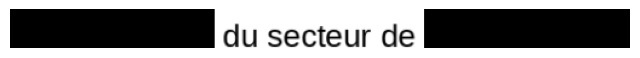

GT   : du secteur de
Pred : du secteur de
CER  : 0.0
--------------------------------------------------


In [ ]:
from utils import compute_cer

sample = next(iter(test_loader))
images, labels, label_lengths = sample

images = images.to(device)

with torch.no_grad():
    logits = model(images)

preds = greedy_decode(logits, tokenizer)

images = images.cpu()
labels = labels.cpu()
label_lengths = label_lengths.cpu()

offset = 0

for i in range(len(label_lengths)):
    length = label_lengths[i].item()
    gt = tokenizer.decode(labels[offset:offset+length].tolist())
    offset += length

    pred = preds[i]

    # calcul du CER
    cer = compute_cer(pred, gt)

    img = images[i].squeeze(0)

    plt.figure(figsize=(8,2))
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.show()

    print("GT   :", gt)
    print("Pred :", pred)
    print("CER  :", round(cer, 4))
    print("-"*50)